<a href="https://colab.research.google.com/github/SahilKamble-dev/it-DS-With-Python---Lab--experiments/blob/main/EXPERIMENT_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Experiment No : 05**

**Aim :**

Learn use of seaborn library as visualisation tool in data science pipeline.

**Visualization with Seaborn**

Matplotlib has proven to be an incredibly useful and popular visualization tool, but even avid users will admit it often leaves much to be desired. There are several valid complaints about Matplotlib that often come up:

Prior to version 2.0, Matplotlib's defaults are not exactly the best choices. It was based off of MATLAB circa 1999, and this often shows.
Matplotlib's API is relatively low level. Doing sophisticated statistical visualization is possible, but often requires a lot of boilerplate code.
Matplotlib predated Pandas by more than a decade, and thus is not designed for use with Pandas DataFrames. In order to visualize data from a Pandas DataFrame, you must extract each Series and often concatenate them together into the right format. It would be nicer to have a plotting library that can intelligently use the DataFrame labels in a plot.

An answer to these problems is Seaborn. Seaborn provides an API on top of Matplotlib that offers sane choices for plot style and color defaults, defines simple high-level functions for common statistical plot types, and integrates with the functionality provided by Pandas DataFrames.

To be fair, the Matplotlib team is addressing this: it has recently added the plt.style tools discussed in Customizing Matplotlib: Configurations and Style Sheets, and is starting to handle Pandas data more seamlessly. The 2.0 release of the library will include a new default stylesheet that will improve on the current status quo. But for all the reasons just discussed, Seaborn remains an extremely useful addon.

**Seaborn Versus Matplotlib**

Here is an example of a simple random-walk plot in Matplotlib, using its classic plot formatting and colors. We start with the typical imports:

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('classic')
%matplotlib inline
import numpy as np
import pandas as pd

In [ ]:
# Create some data
rng = np.random.RandomState(0)
x = np.linspace(0, 10, 500)
y = np.cumsum(rng.randn(500, 6), 0)

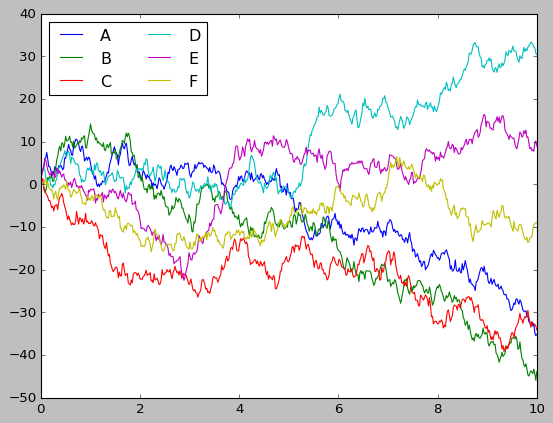

In [ ]:
# Plot the data with Matplotlib defaults
plt.plot(x, y)
plt.legend('ABCDEF', ncol=2, loc='upper left');

Although the result contains all the information we'd like it to convey, it does so in a way that is not all that aesthetically pleasing, and even looks a bit old-fashioned in the context of 21st-century data visualization.

Now let's take a look at how it works with Seaborn. As we will see, Seaborn has many of its own high-level plotting routines, but it can also overwrite Matplotlib's default parameters and in turn get even simple Matplotlib scripts to produce vastly superior output. We can set the style by calling Seaborn's set() method. By convention, Seaborn is imported as sns:

In [ ]:
import seaborn as sns
sns.set()

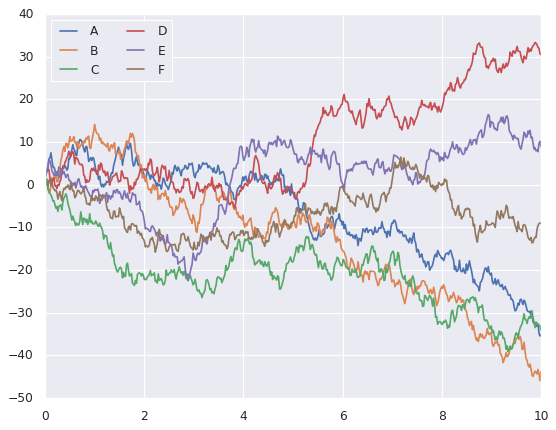

In [ ]:
# same plotting code as above!
plt.plot(x, y)
plt.legend('ABCDEF', ncol=2, loc='upper left');


**Exploring Seaborn Plots**

The main idea of Seaborn is that it provides high-level commands to create a variety of plot types useful for statistical data exploration, and even some statistical model fitting.

Let's take a look at a few of the datasets and plot types available in Seaborn. Note that all of the following could be done using raw Matplotlib commands (this is, in fact, what Seaborn does under the hood) but the Seaborn API is much more convenient.

**Histograms, KDE, and densities**

Often in statistical data visualization, all you want is to plot histograms and joint distributions of variables. We have seen that this is relatively straightforward in Matplotlib:

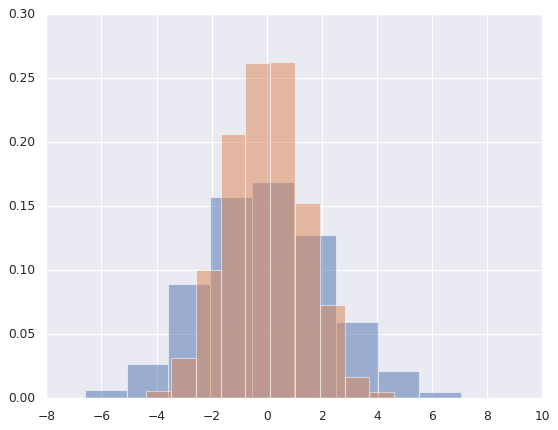

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate random multivariate data
data = np.random.multivariate_normal([0, 0], [[5, 2], [2, 2]], size=2000)

# Convert to DataFrame
data = pd.DataFrame(data, columns=['x', 'y'])

# Plot histogram
for col in 'xy':
    plt.hist(data[col], density=True, alpha=0.5)

plt.show()

/tmp/ipykernel_1015/4143655892.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data[col], shade=True)
/tmp/ipykernel_1015/4143655892.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data[col], shade=True)


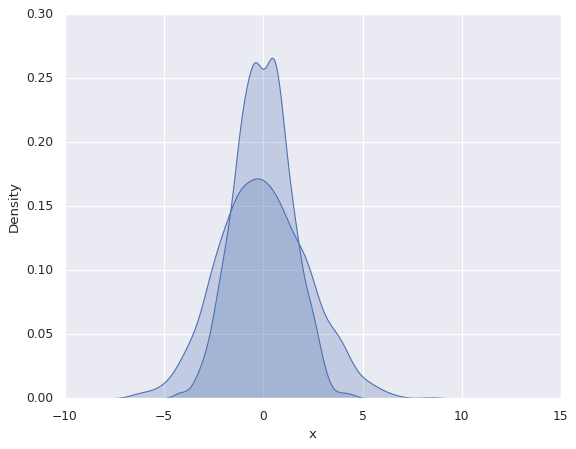

In [ ]:
for col in 'xy':
    sns.kdeplot(data[col], shade=True)

/tmp/ipykernel_1015/923662334.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['x'])
/tmp/ipykernel_1015/923662334.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['y']);


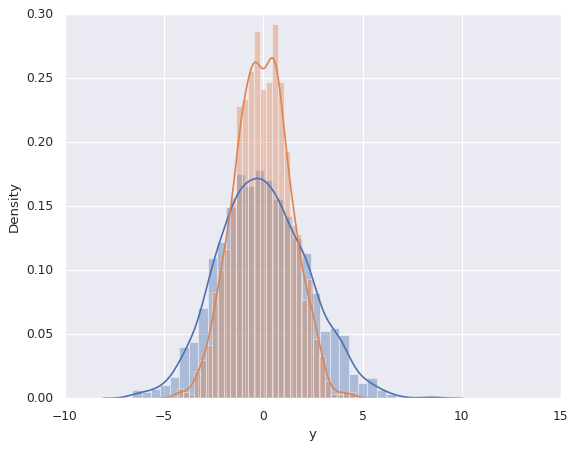

In [ ]:
sns.distplot(data['x'])
sns.distplot(data['y']);

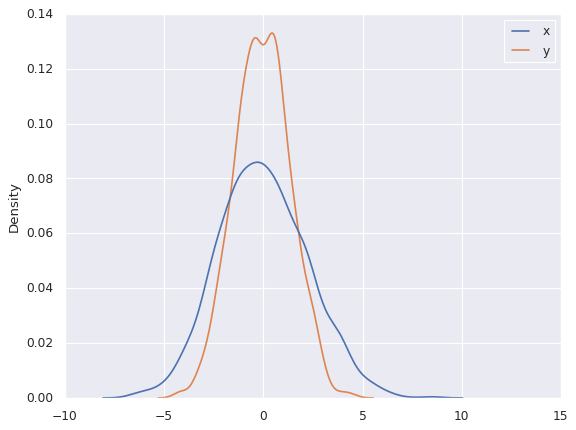

In [ ]:
sns.kdeplot(data);

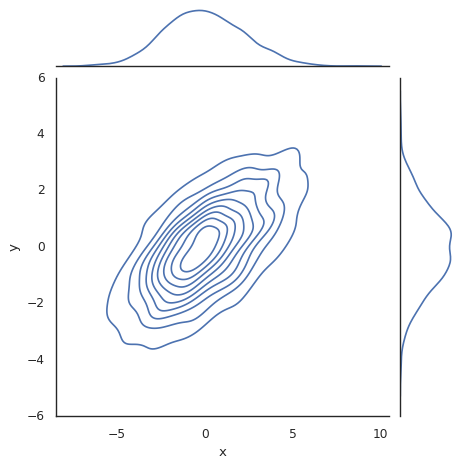

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

with sns.axes_style('white'):
    sns.jointplot(x="x", y="y", data=data, kind='kde')

plt.show()

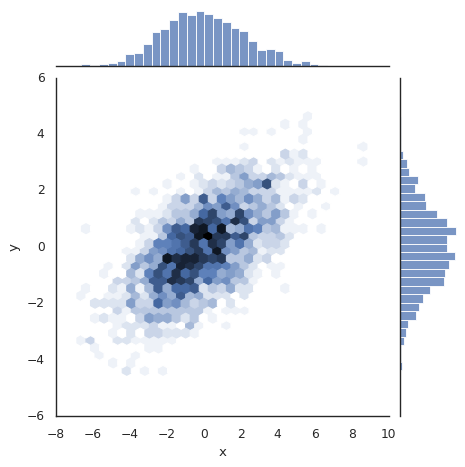

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

with sns.axes_style('white'):
    sns.jointplot(x="x", y="y", data=data, kind='hex')

plt.show()

**Pair plots**

When you generalize joint plots to datasets of larger dimensions, you end up with pair plots. This is very useful for exploring correlations between multidimensional data, when you'd like to plot all pairs of values against each other.

We'll demo this with the well-known Iris dataset, which lists measurements of petals and sepals of three iris species:

In [ ]:
iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


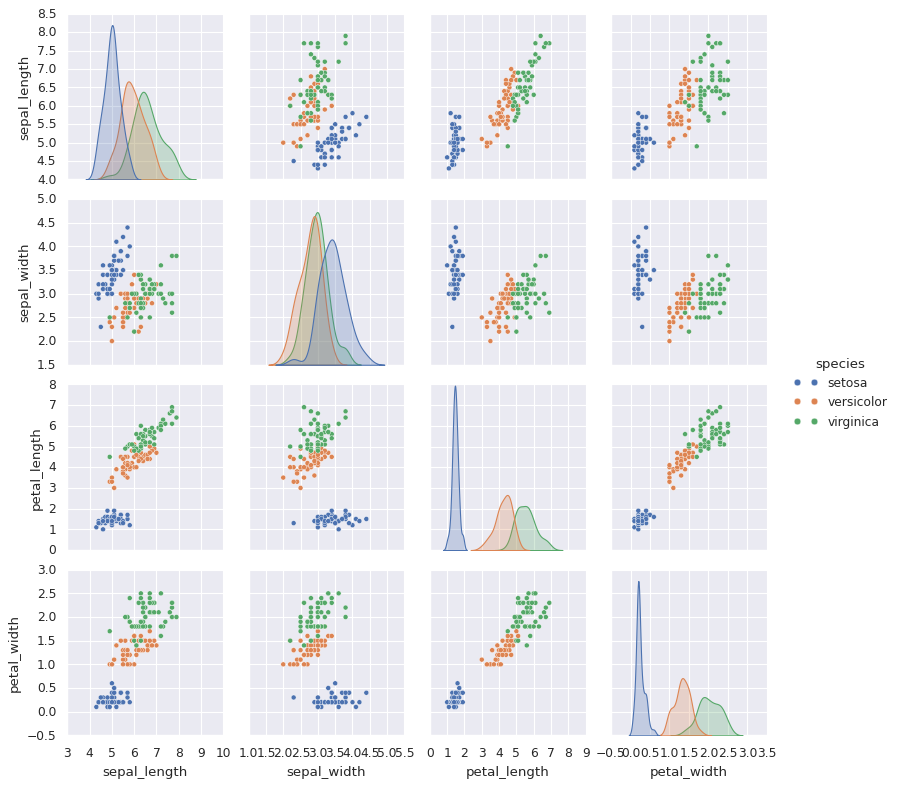

In [ ]:
sns.pairplot(iris, hue='species', size=2.5);

**Faceted histograms**

In [ ]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


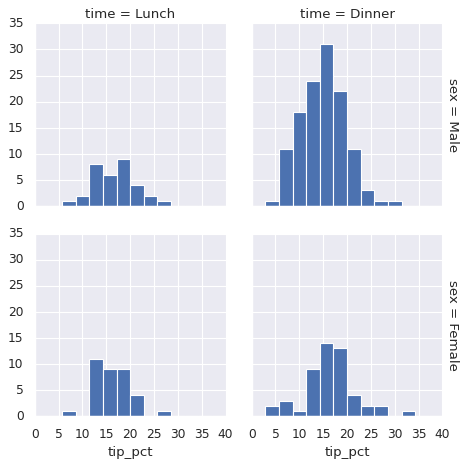

In [ ]:
tips['tip_pct'] = 100 * tips['tip'] / tips['total_bill']

grid = sns.FacetGrid(tips, row="sex", col="time", margin_titles=True)
grid.map(plt.hist, "tip_pct", bins=np.linspace(0, 40, 15));

**Factor plots**

Factor plots can be useful for this kind of visualization as well. This allows you to view the distribution of a parameter within bins defined by any other parameter:

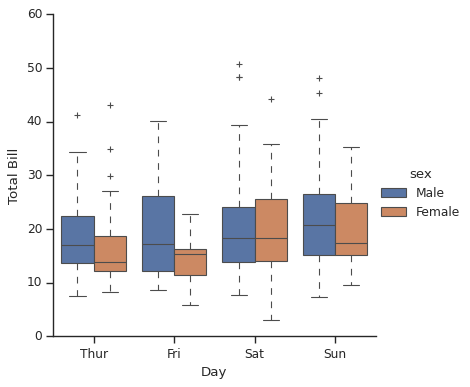

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")

with sns.axes_style(style='ticks'):
    g = sns.catplot(x="day", y="total_bill", hue="sex", data=tips, kind="box")

g.set_axis_labels("Day", "Total Bill")

plt.show()

**Joint distributions**

Similar to the pairplot we saw earlier, we can use sns.jointplot to show the joint distribution between different datasets, along with the associated marginal distributions:

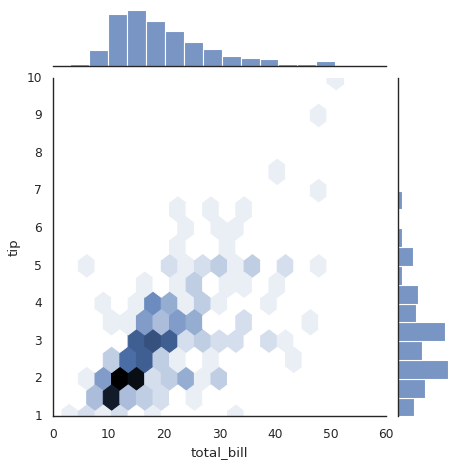

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")

with sns.axes_style('white'):
    sns.jointplot(x="total_bill", y="tip", data=tips, kind='hex')

plt.show()

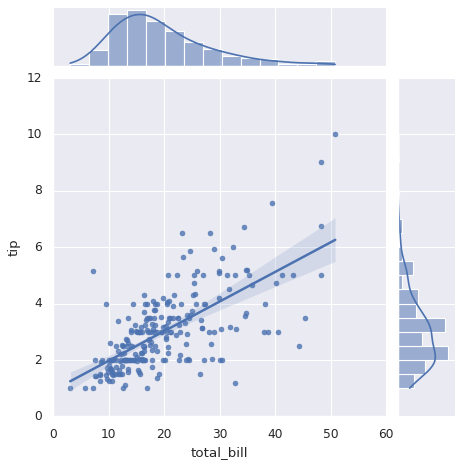

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")

sns.jointplot(x="total_bill", y="tip", data=tips, kind='reg')

plt.show()

**Bar plots**

Time series can be plotted using sns.factorplot. In the following example, we'll use the Planets data that we first saw in Aggregation and Grouping:

In [ ]:
planets = sns.load_dataset('planets')
planets.head()

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


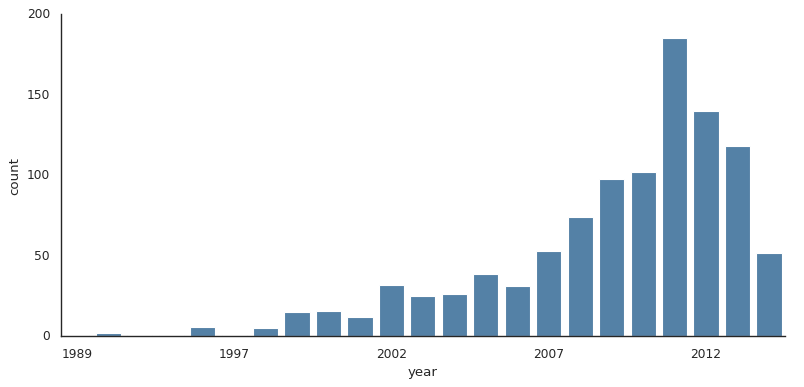

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

planets = sns.load_dataset("planets")

with sns.axes_style('white'):
    g = sns.catplot(x="year", data=planets, aspect=2,
                    kind="count", color='steelblue')

g.set_xticklabels(step=5)

plt.show()

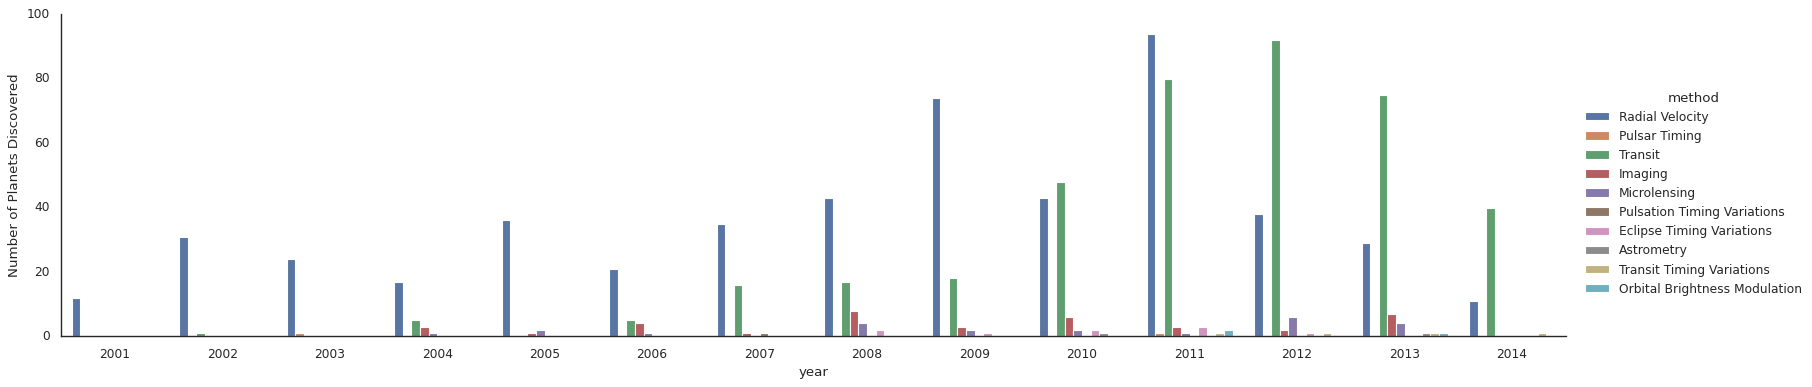

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

planets = sns.load_dataset("planets")

with sns.axes_style('white'):
    g = sns.catplot(x="year", data=planets, aspect=4.0, kind='count',
                    hue='method', order=range(2001, 2015))

g.set_ylabels('Number of Planets Discovered')

plt.show()

**Example: Exploring Marathon Finishing Times**

Here we'll look at using Seaborn to help visualize and understand finishing results from a marathon. I've scraped the data from sources on the Web, aggregated it and removed any identifying information, and put it on GitHub where it can be downloaded (if you are interested in using Python for web scraping, I would recommend Web Scraping with Python by Ryan Mitchell). We will start by downloading the data from the Web, and loading it into Pandas:

In [ ]:
data.dtypes

,0
x,float64
y,float64


In [ ]:
data.dtypes

,0
x,float64
y,float64


The dotted line shows where someone's time would lie if they ran the marathon at a perfectly steady pace. The fact that the distribution lies above this indicates (as you might expect) that most people slow down over the course of the marathon. If you have run competitively, you'll know that those who do the opposite—run faster during the second half of the race—are said to have "negative-split" the race.

Let's create another column in the data, the split fraction, which measures the degree to which each runner negative-splits or positive-splits the race:

In [ ]:
data.rename(columns={'M/F':'gender'}, inplace=True)

In [ ]:
data.rename(columns={'M/F': 'gender'}, inplace=True)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.lmplot(
    x='final_sec',
    y='split_frac',
    col='M/F',      # use this if your dataset column is M/F
    data=data,
    markers=".",
    scatter_kws=dict(color='c')
)

g.map(plt.axhline, y=0.5, color="k", ls=":")

plt.show()

KeyError: "None of [Index(['M/F', 'final_sec', 'split_frac'], dtype='object')] are in the [columns]"

Apparently the people with fast splits are the elite runners who are finishing within ~15,000 seconds, or about 4 hours. People slower than that are much less likely to have a fast second split.

**Conclusion:**

Thus we have learned about seaborn python API used for graph ploting.